In [45]:
# Linier Regression Model Biaya Kesehatan

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

from google.colab import drive
drive.mount('/content/drive')

folder = "/content/drive/MyDrive/[02] Work/BelajarDataScience/Dataset/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
# 1. Load Data

df=pd.read_csv("/content/drive/MyDrive/[02] Work/BelajarDataScience/Dataset/StudentPerformanceFactorsCleanNew.csv")
# display(df.head())

# 2. Pisahkan Feature dan Target
x = df.drop(["Exam_Score", "Access_to_Resources", "Academic_Status", "Sleep_Hours", "Motivation_Level", "Family_Income", "Teacher_Quality", "Learning_Disabilities", "Gender", "School_Type", "Parental_Involvement"], axis=1)
y = df["Exam_Score"]

# Encoding Kategorikal
x = pd.get_dummies(x, drop_first=True)
display(x)

# 3. Split Data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
    )

# 4. Buat dan Latih Model
model_lr = LinearRegression()
model_dt = DecisionTreeRegressor(random_state=42)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Training
model_lr.fit(x_train, y_train)
model_dt.fit(x_train, y_train)
model_rf.fit(x_train, y_train)

# 5. Prediksi
pred_lr = model_lr.predict(x_test)
pred_dt = model_dt.predict(x_test)
pred_rf = model_rf.predict(x_test)

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Physical_Activity,Extracurricular_Activities_Yes,Internet_Access_Yes,Peer_Influence_Neutral,Peer_Influence_Positive,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near
0,23,84,73,0,3,False,True,False,True,True,False,False,True
1,19,64,59,2,4,False,True,False,False,False,False,True,False
2,24,98,91,2,4,True,True,True,False,False,True,False,True
3,29,89,98,1,4,True,True,False,False,True,False,True,False
4,19,92,65,3,4,True,True,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6468,25,69,76,1,2,False,True,False,True,True,False,False,True
6469,23,76,81,3,2,False,True,False,True,True,False,False,True
6470,20,90,65,3,2,True,True,False,False,False,True,False,True
6471,10,86,91,2,3,True,True,False,True,True,False,False,False


In [61]:
# 6. Eveluasi Model
def evaluasi(nama, y_test, pred):
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print("\n====== Hasil Evaluasi Model ======")
    print(f"Model: {nama}")
    print(f"MAE: ", mae)
    print(f"RMSE: ", rmse)
    print(f"R2: ", r2)

    return r2

r2_lr = evaluasi("Linear Regression", y_test, pred_lr)
r2_dt = evaluasi("Decision Tree", y_test, pred_dt)
r2_rf = evaluasi("Random Forest", y_test, pred_rf)


====== Hasil Evaluasi Model ======
Model: Linear Regression
MAE:  0.9661642989002495
RMSE:  1.1947730931934872
R2:  0.8619962835170217

====== Hasil Evaluasi Model ======
Model: Decision Tree
MAE:  1.5328185328185329
RMSE:  1.9604191498868917
R2:  0.6284495535490386

====== Hasil Evaluasi Model ======
Model: Random Forest
MAE:  1.0776447876447874
RMSE:  1.348787214428929
R2:  0.824123912379279


In [62]:
# 7. Koefisien Model
coef_df = pd.DataFrame({
    "Feature": x.columns,
    "Koefisien": model_lr.coef_
}).sort_values(by="Koefisien", ascending=False)
print("\n====== Koefisien Model ======")
print(coef_df)
print("\nIntercept: ", model_lr.intercept_)

# 8. Simpan Model
joblib.dump(model_lr, folder + "model_student_performance_factor.pkl")
print("\nModel berhasil disimpan!")


====== Koefisien Model ======
                                  Feature  Koefisien
8                 Peer_Influence_Positive   1.075134
6                     Internet_Access_Yes   1.002231
12                Distance_from_Home_Near   0.941533
7                  Peer_Influence_Neutral   0.538316
5          Extracurricular_Activities_Yes   0.492132
3                       Tutoring_Sessions   0.484201
10  Parental_Education_Level_Postgraduate   0.459020
11            Distance_from_Home_Moderate   0.423431
0                           Hours_Studied   0.292456
1                              Attendance   0.197459
4                       Physical_Activity   0.196885
2                         Previous_Scores   0.048741
9    Parental_Education_Level_High School  -0.487155

Intercept:  38.06446787080266

Model berhasil disimpan!


In [63]:
# 9. Seleksi Model Terbaik
score = {
    "Linier Regression": r2_lr,
    "Decision Tree": r2_dt,
    "Random Forest": r2_rf
}

model_terbaik = max(score, key=score.get)
print("\nModel Terbaik: ", model_terbaik)


Model Terbaik:  Linier Regression


In [64]:
# 10. Simpan Semua Model

joblib.dump(model_lr, folder + "model_student_logistic_regression.pkl")
joblib.dump(model_dt, folder + "model_student_decision_tree.pkl")
joblib.dump(model_rf, folder + "model_student_random_forest.pkl")
print("\nModel berhasil disimpan!")

# Simpan dalam satu file
semua_model = {
    "logistic": model_lr,
    "decision_tree": model_dt,
    "random_forest": model_rf
}

joblib.dump(semua_model, folder + "semua_model.pkl")


Model berhasil disimpan!


['/content/drive/MyDrive/[02] Work/BelajarDataScience/Dataset/semua_model.pkl']

In [75]:
# Load Data dan Model

df = pd.read_csv(folder + "StudentPerformanceFactorsCleanNew.csv")
model = joblib.load(folder + "model_student_logistic_regression.pkl")
print(model)

# Siapkan Fitur seperti saat training
x = pd.get_dummies(
    df.drop(["Exam_Score", "Access_to_Resources", "Academic_Status", "Sleep_Hours", "Motivation_Level", "Family_Income", "Teacher_Quality", "Learning_Disabilities", "Gender", "School_Type", "Parental_Involvement"], axis=1),
    drop_first=True)

y = df["Exam_Score"]

LinearRegression()


In [67]:
# Hitung Error Model (Evaluasi Ulang)

y_pred_all = model.predict(x)

mae = mean_absolute_error(y, y_pred_all)
rmse = np.sqrt(mean_squared_error(y, y_pred_all))
r2 = r2_score(y, y_pred_all)

print("\n====== Hasil Evaluasi Model ======")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")


====== Hasil Evaluasi Model ======
MAE: 0.979
RMSE: 1.214
R2: 0.859


In [77]:
# Membaca Input Dari User

print("\n====== Masukkan Data Baru ======")
hour_studied = int(input("Durasi Belajar (Jam) : "))
attendance = int(input("Prosentase Kehadiran (%) : "))
extracurricular_activities = input("Ikut Kegiatan Ekstra (Yes/No) : ")
previous_scores = int(input("Nilai Sebelumnya (0-100) : "))
internet_access = input("Kepemilikan Akses Internet (Yes/No) : ")
tutoring_sessions = int(input("Jumlah sesi bimbingan belajar (les/tutor) yang diikuti siswa : "))
peer_influence = input("Pengaruh Teman Sebaya (Positive/Negative) : ")
physical_activity = int(input("Frekuensi Aktivitas Fisik Siswa (Jam/Minggu) : "))
parental_education_level = input("Tingkat pendidikan orang tua siswa (High School/College/Postgraduate) : ")
distance_from_home = input("Jarak ke sekolah (Near/Moderate/Far) : ")

# Buat Dataframe Input

input_dist = {
    "Hours_Studied": [hour_studied],
    "Attendance": [attendance],
    "Extracurricular_Activities": [extracurricular_activities],
    "Previous_Scores": [previous_scores],
    "Internet_Access": [internet_access],
    "Tutoring_Sessions": [tutoring_sessions],
    "Peer_Influence": [peer_influence],
    "Physical_Activity": [physical_activity],
    "Parental_Education_Level": [parental_education_level],
    "Distance_From_Home": [distance_from_home]
}

# Encoding
input_df = pd.DataFrame(input_dist)
display(input_df)

# Samakan Kolom
input_df = input_df.reindex(columns=x.columns, fill_value=0)


====== Masukkan Data Baru ======
Durasi Belajar (Jam) : 24
Prosentase Kehadiran (%) : 98
Ikut Kegiatan Ekstra (Yes/No) : Yes
Nilai Sebelumnya (0-100) : 91
Kepemilikan Akses Internet (Yes/No) : Yes
Jumlah sesi bimbingan belajar (les/tutor) yang diikuti siswa : 2
Pengaruh Teman Sebaya (Positive/Negative) : Neutral
Frekuensi Aktivitas Fisik Siswa (Jam/Minggu) : 4
Tingkat pendidikan orang tua siswa (High School/College/Postgraduate) : Postgraduate
Jarak ke sekolah (Near/Moderate/Far) : Near


,Hours_Studied,Attendance,Extracurricular_Activities,Previous_Scores,Internet_Access,Tutoring_Sessions,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_From_Home
0,24,98,Yes,91,Yes,2,Neutral,4,Postgraduate,Near


In [78]:
# Prediksi

prediksi = model.predict(input_df)

print("\n====== Hasil Prediksi ======")
print(f"Nilai Ujian: {prediksi[0]:.2f} (0-100)")
print(f"Rata-rata kesalahan model (MAE): +-{mae:.2f} ")


====== Hasil Prediksi ======
Nilai Ujian: 70.63 (0-100)
Rata-rata kesalahan model (MAE): +-0.98 


In [71]:
# Attendance vs Exam_Score

x1 = df[["Attendance"]]
y1 = df["Exam_Score"]

model1 = LinearRegression()
model1.fit(x1, y1)

LinearRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


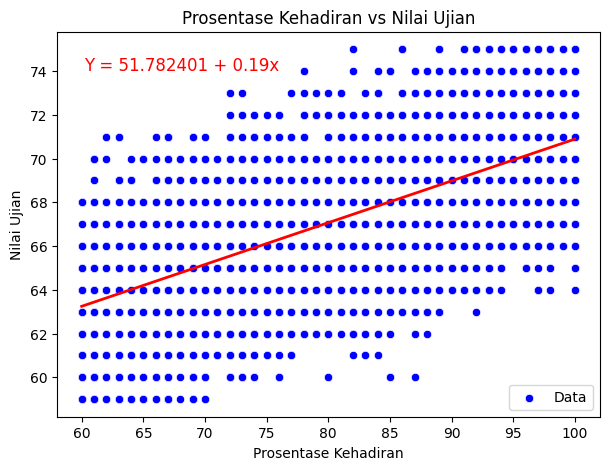

In [72]:
# Menggambar garis regresi Nilai Ujian dan Kehadiran

x_range1 = np.linspace(x1.min(), x1.max(), 100).reshape(-1, 1)
y_pred1 = model1.predict(x_range1)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Attendance", y="Exam_Score", color="blue", label="Data")
plt.plot(x_range1, y_pred1, color="red", linewidth=2, label="Regresi")

persamaan1 = f"Y = {model1.intercept_:2f} + {model1.coef_[0]:.2f}x"
plt.text(0.05, 0.9, persamaan1, transform=plt.gca().transAxes, fontsize=12, color="red")

plt.xlabel("Prosentase Kehadiran")
plt.ylabel("Nilai Ujian")
plt.title("Prosentase Kehadiran vs Nilai Ujian")
plt.show()


In [73]:
# Lama Belajar vs Nilai Ujian

x2 = df[["Hours_Studied"]]
y2 = df["Exam_Score"]

model2 = LinearRegression()
model2.fit(x2, y2)

LinearRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


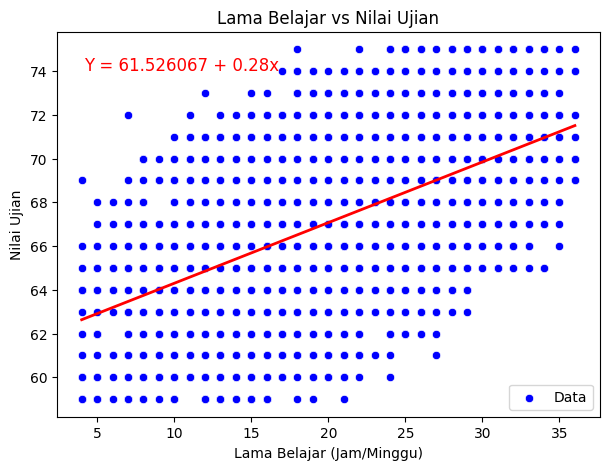

In [74]:
# Menggambar garis regresi Lama Belajar vs Nilai Ujian

x_range2 = np.linspace(x2.min(), x2.max(), 100).reshape(-1, 1)
y_pred2 = model2.predict(x_range2)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score", color="blue", label="Data")
plt.plot(x_range2, y_pred2, color="red", linewidth=2, label="Regresi")

persamaan2 = f"Y = {model2.intercept_:2f} + {model2.coef_[0]:.2f}x"
plt.text(0.05, 0.9, persamaan2, transform=plt.gca().transAxes, fontsize=12, color="red")

plt.xlabel("Lama Belajar (Jam/Minggu)")
plt.ylabel("Nilai Ujian")
plt.title("Lama Belajar vs Nilai Ujian")
plt.show()